In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("data/marketing_clean.csv")
print("Shape:", df.shape)
df.head()

Shape: (56000, 37)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Country,Age,Total_Spend,Total_Purchase,Children,Customer_Tenure,Avg_Order_Value,Web_Conversion_Rate,Age_Band,Income_Band
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,Spain,41,69,13,1,4974,5.31,0.50,40-49,50-75k
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,Spain,51,39,4,2,4830,9.75,0.33,50-59,<25k
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,Australia,48,1512,12,0,4554,126.00,0.67,40-49,75-100k
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,Spain,50,478,16,1,4396,29.88,1.00,50-59,50-75k
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,Canada,45,330,9,2,4425,36.67,0.50,40-49,50-75k


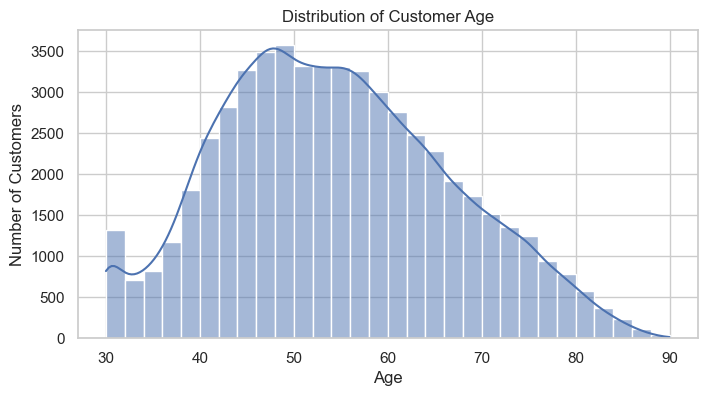

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

### Takeaway — Age Distribution
- Customer base peaks at **45–50**; predominantly mature adults (40–60).
- **No customers under 30** — the under-30 market is unrepresented.
- Right-skewed tail into the 70s–80s.
- **Action:** target campaigns at mature adults, not youth.

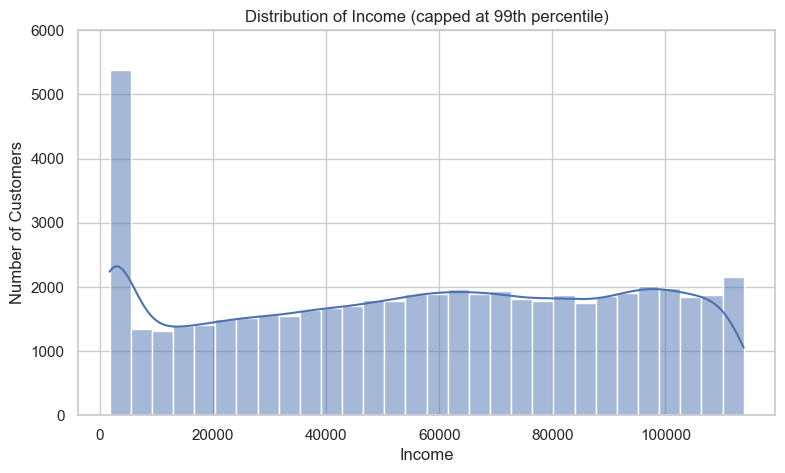

In [12]:
income_capped = df['Income'].clip(upper=df['Income'].quantile(0.99))

plt.figure(figsize=(9, 5))
sns.histplot(income_capped, bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of Income (capped at 99th percentile)")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.yticks(range(0, 7000, 1000))
plt.show()

### Takeaway — Income Distribution (capped at 99th percentile)
- A large **spike of very low-income customers** (~5,300) sits at the far left.
- After that dip, income spreads out and **climbs steadily** from ~15k up to ~100k — most customers are low-to-upper-middle earners.
- The **right-edge bar holds the capped high-earners** (99th percentile+); genuinely high incomes are rare.
- **Overall:** right-skewed, with a low-income cluster plus a broad middle-income base.
- **Why capped:** a few customers earn up to ₹258k; capping at the 99th percentile keeps the chart readable *without deleting* those real customers.

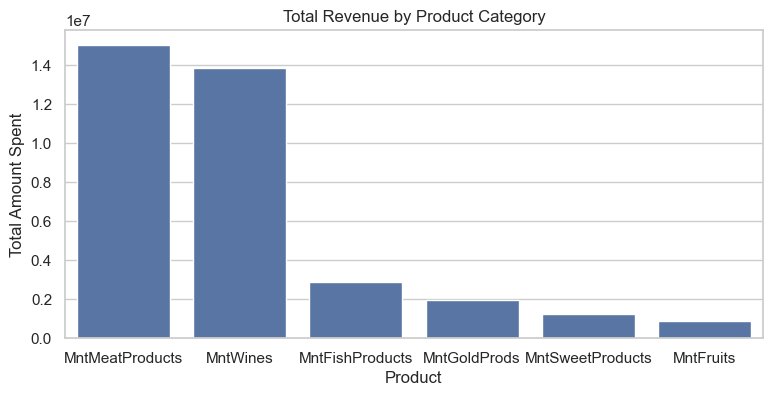

In [7]:
products = ['MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

product_totals = df[products].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=product_totals.index, y=product_totals.values)
plt.title("Total Revenue by Product Category")
plt.ylabel("Total Amount Spent")
plt.xlabel("Product")
plt.show()

### Takeaway — Revenue by Product Category
- **Meat and Wine dominate**, together making up roughly **80% of all revenue**.
- **Fish, Gold, Sweets, and Fruits are minor** — each a small fraction of the top two.
- **Action:** future campaigns should lead with **wine + meat** offers/bundles; these are what customers actually spend on. Don't waste premium budget promoting fruits/sweets.

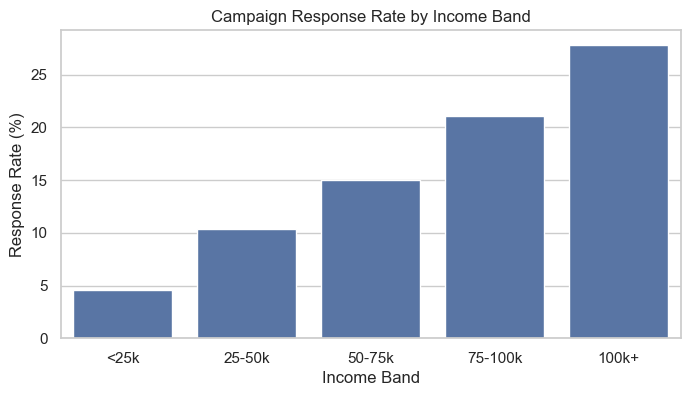

In [14]:
band_order = ['<25k', '25-50k', '50-75k', '75-100k', '100k+']

response_by_income = (df.groupby('Income_Band')['Response'].mean() * 100).reindex(band_order)

plt.figure(figsize=(8, 4))
sns.barplot(x=response_by_income.index, y=response_by_income.values)
plt.title("Campaign Response Rate by Income Band")
plt.ylabel("Response Rate (%)")
plt.xlabel("Income Band")
plt.show()

### Takeaway — Response Rate by Income Band
- Response rate **climbs steadily with income**: 4.6% (<25k) → 28% (100k+).
- That's a **~6× difference** — income is the **single strongest predictor** of campaign response.
- **Action:** prioritise high-income customers (75k+) for premium campaigns; low-income bands convert poorly.

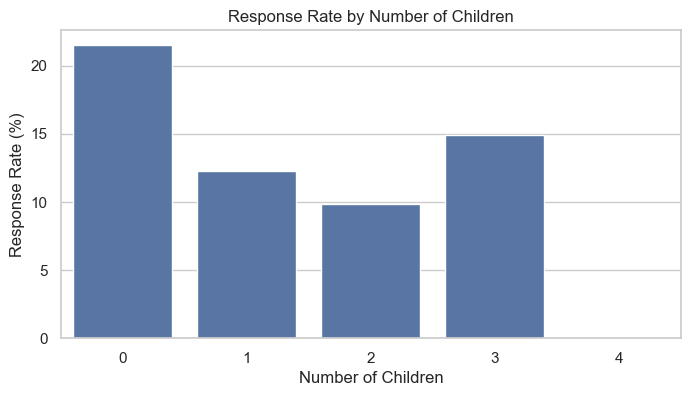

In [16]:
response_by_children = df.groupby('Children')['Response'].mean() * 100

plt.figure(figsize=(8, 4))
sns.barplot(x=response_by_children.index, y=response_by_children.values)
plt.title("Response Rate by Number of Children")
plt.ylabel("Response Rate (%)")
plt.xlabel("Number of Children")
plt.show()

In [17]:
df['Children'].value_counts()

Children
1    26484
0    17778
2    11189
3      543
4        6
Name: count, dtype: int64

###  Takeaway — Response Rate by Number of Children
- Customers with **no children respond most (~21.5%)** — about **2× higher** than those with kids.
- Response **declines** from 0 → 1 → 2 children (21.5% → 12% → 9.7%).
- The "3 children" uptick is **ignored** — only 543 customers (too small to be reliable).
- **Action:** target **childless customers** for campaigns; combined with the income finding, the ideal target is **high-income + no children**.

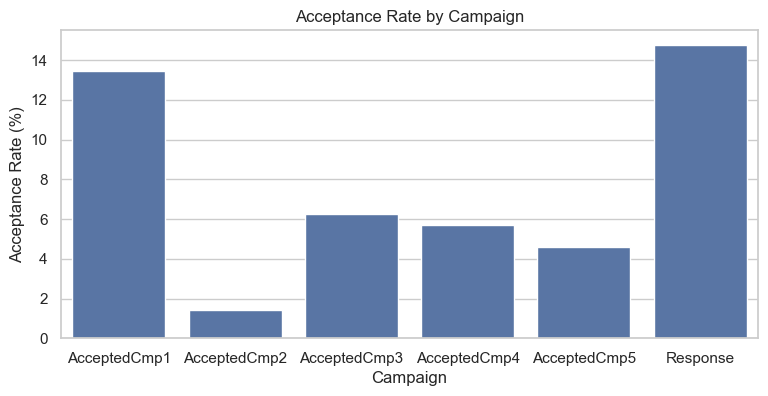

In [18]:
campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
             'AcceptedCmp4', 'AcceptedCmp5', 'Response']

campaign_rates = df[campaigns].mean() * 100

plt.figure(figsize=(9, 4))
sns.barplot(x=campaign_rates.index, y=campaign_rates.values)
plt.title("Acceptance Rate by Campaign")
plt.ylabel("Acceptance Rate (%)")
plt.xlabel("Campaign")
plt.show()

###  Takeaway — Campaign Performance
- The **last campaign (14.8%)** and **Campaign 1 (13.4%)** were the clear winners.
- **Campaign 2 failed badly (1.4%)** — ~10× worse than the best.
- Campaigns 3–5 were mediocre (4–6%).
- **Action:** **retire or redesign Campaign 2**; model future campaigns on the playbook of the last campaign and Campaign 1.

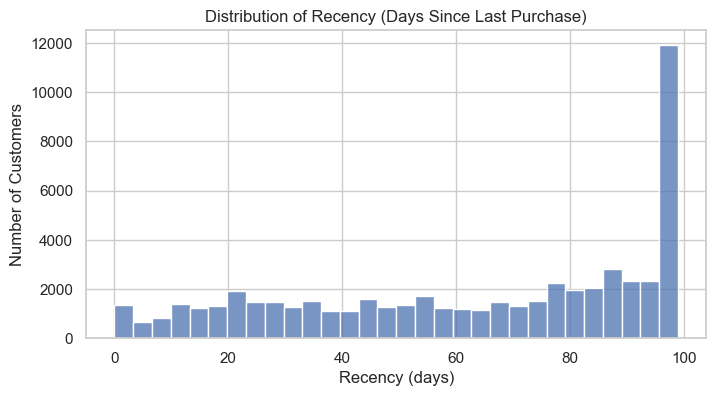

In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Recency'], bins=30)
plt.title("Distribution of Recency (Days Since Last Purchase)")
plt.xlabel("Recency (days)")
plt.ylabel("Number of Customers")
plt.show()

In [20]:
df['Recency'].value_counts().sort_index(ascending=False).head()


Recency
99    9645
98     784
97     732
96     762
95     780
Name: count, dtype: int64

###  Takeaway — Recency Distribution
- Even spread of recency 0–95 days.
- **Recency is capped at 99** — 9,645 customers sit at exactly 99, meaning "99+ days" (confirmed via value_counts).
- This large **cold-customer group** is a **win-back/re-engagement** target.

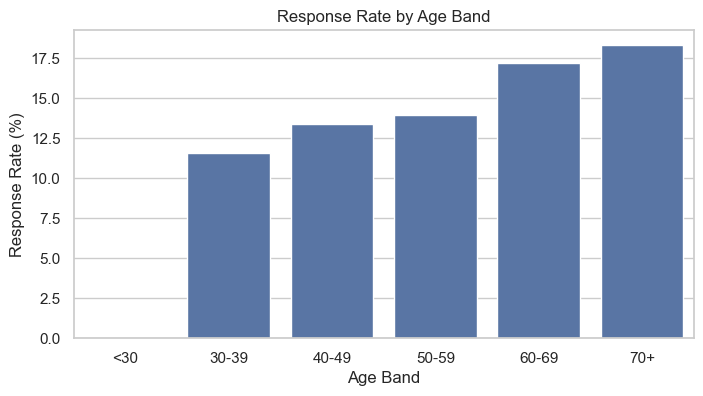

In [24]:
age_order = ['<30', '30-39', '40-49', '50-59', '60-69', '70+']

response_by_age = (df.groupby('Age_Band')['Response'].mean() * 100).reindex(age_order)

plt.figure(figsize=(8, 4))
sns.barplot(x=response_by_age.index, y=response_by_age.values)
plt.title("Response Rate by Age Band")
plt.ylabel("Response Rate (%)")
plt.xlabel("Age Band")
plt.show()

### Takeaway — Response Rate by Age Band
- Response rate **rises with age**: ~11.5% (30s) → ~18% (70+).
- A **moderate** effect — weaker than income, but consistent.
- (No under-30 customers exist, so that band is empty.)
- **Adds to the ideal-customer profile:** older skews more responsive.

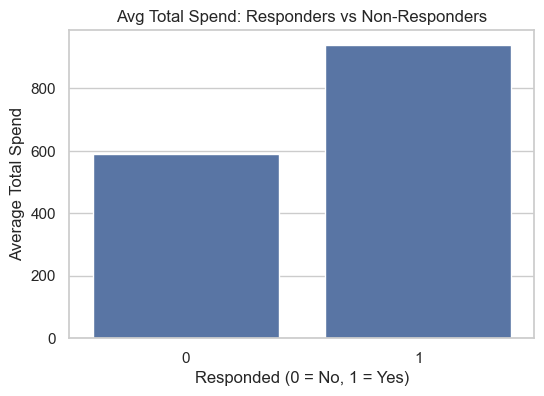

In [26]:
spend_by_response = df.groupby('Response')['Total_Spend'].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=spend_by_response.index, y=spend_by_response.values)
plt.title("Avg Total Spend: Responders vs Non-Responders")
plt.xlabel("Responded (0 = No, 1 = Yes)")
plt.ylabel("Average Total Spend")
plt.show()

###  Takeaway — Spend vs Response
- Responders spend **~60% more** (₹939 vs ₹589) than non-responders.
- **Prior spend is a strong response signal** — target existing high-spenders.

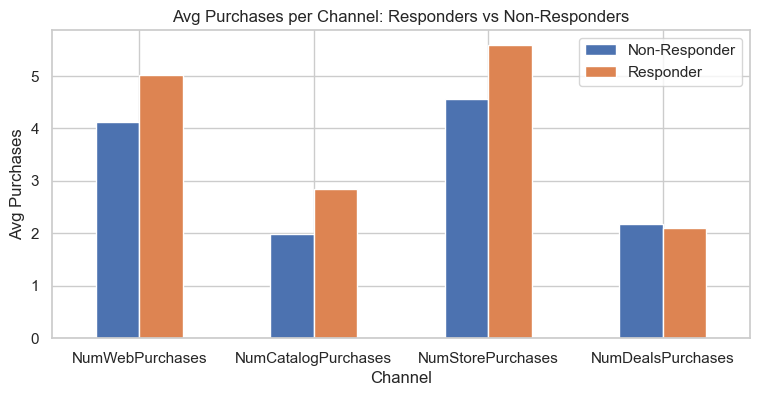

In [27]:
channels = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']
channel_by_response = df.groupby('Response')[channels].mean()

channel_by_response.T.plot(kind='bar', figsize=(9, 4))
plt.title("Avg Purchases per Channel: Responders vs Non-Responders")
plt.ylabel("Avg Purchases")
plt.xlabel("Channel")
plt.xticks(rotation=0)
plt.legend(["Non-Responder", "Responder"])
plt.show()

###  Takeaway — Channel Usage vs Response
- Responders buy more via **store, web, and (relatively) catalog**.
- **Deals/discounts are equal** — responders aren't bargain-driven.
- **Action:** reach responsive customers through **catalog & store**, not discount deals.

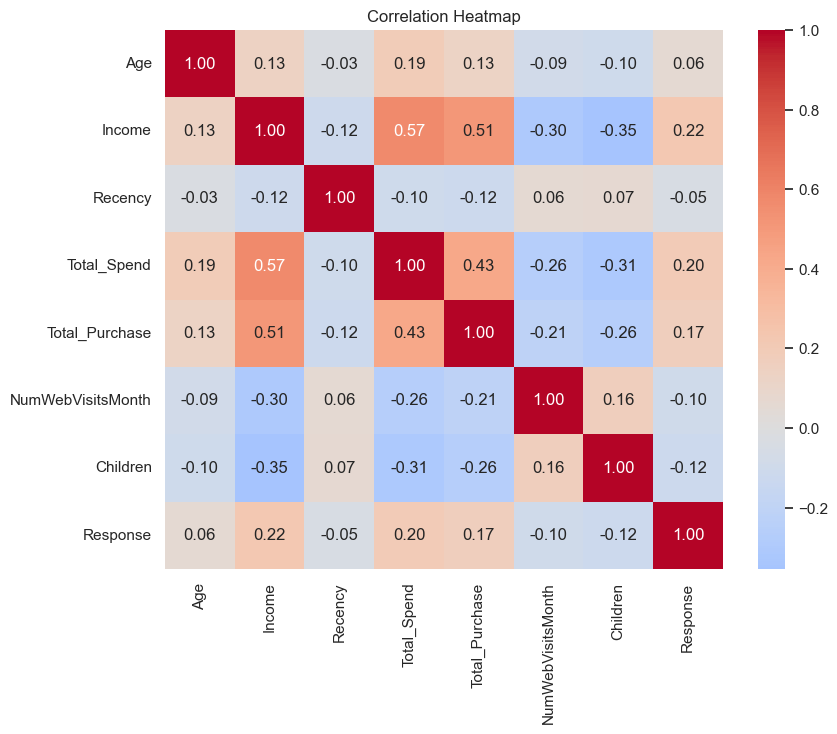

In [28]:
corr_cols = ['Age', 'Income', 'Recency', 'Total_Spend', 'Total_Purchase',
             'NumWebVisitsMonth', 'Children', 'Response']

plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

###  Takeaway — Correlation Heatmap
- **Response** is driven **up** by Income (0.22), Total_Spend (0.20), Total_Purchase (0.17).
- **Response** is driven **down** by Children (−0.12) and Web Visits (−0.10).
- Income strongly powers spending (0.57).
- **Web visits negatively correlate with spend (−0.26)** → heavy site-visitors browse but don't buy.

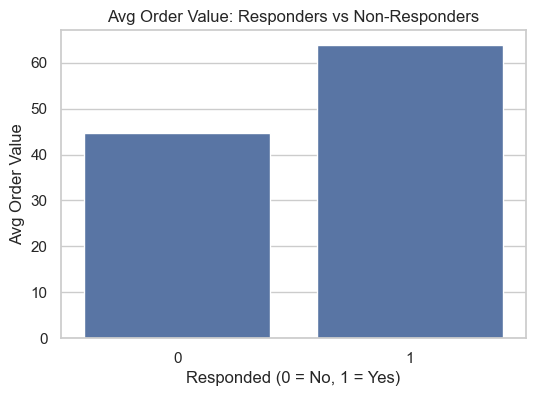

In [29]:
aov_by_response = df.groupby('Response')['Avg_Order_Value'].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=aov_by_response.index, y=aov_by_response.values)
plt.title("Avg Order Value: Responders vs Non-Responders")
plt.xlabel("Responded (0 = No, 1 = Yes)")
plt.ylabel("Avg Order Value")
plt.show()


### Takeaway — Avg Order Value vs Response
- Responders have a **higher Avg Order Value** (~63 vs ~44).
- They don't just buy more often — they buy **bigger baskets per order**.
- **Action:** responders are premium buyers — worth premium offers.

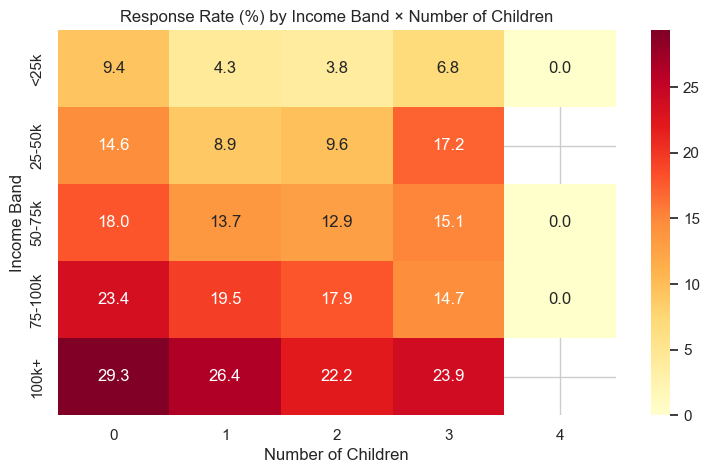

In [30]:
pivot = df.pivot_table(values='Response', index='Income_Band',
                       columns='Children', aggfunc='mean') * 100
pivot = pivot.reindex(['<25k', '25-50k', '50-75k', '75-100k', '100k+'])

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title("Response Rate (%) by Income Band × Number of Children")
plt.ylabel("Income Band")
plt.xlabel("Number of Children")
plt.show()

### Takeaway — Response by Income × Children
- Response peaks at **high-income + no children (29.3%)** — the darkest cell.
- It **rises with income** (going down) and **falls with children** (going right).
- **The single best target cell: 100k+ income, 0 children.**